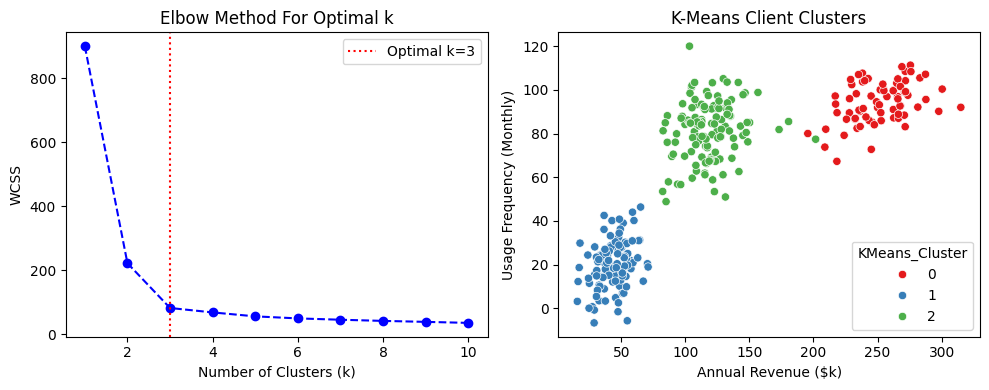

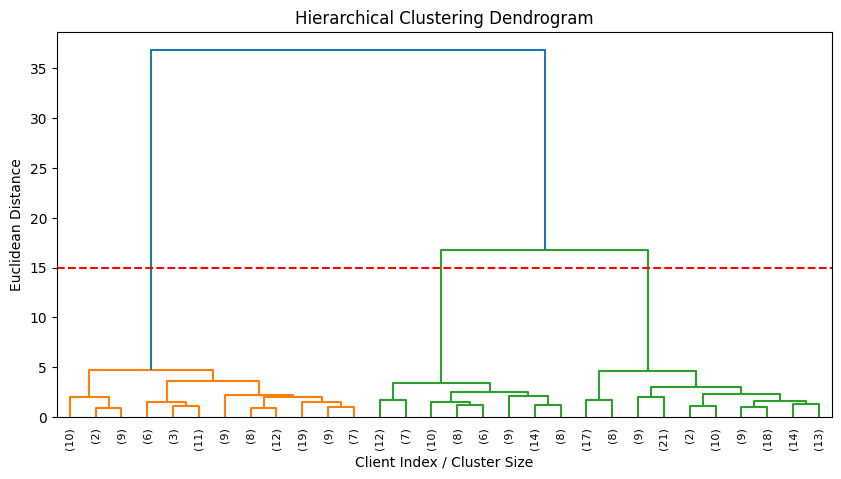


--- Algorithm Comparison Matrix (Crosstab) ---
Hierarchical_Cluster    0   1    2
KMeans_Cluster                    
0                       0  72    0
1                     105   0    0
2                       0   2  121


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# 1. Mock Data Setup
np.random.seed(42)
n_clients = 300
cluster_1 = np.random.multivariate_normal([120, 80, 2], [[400, 100, 5], [100, 225, -2], [5, -2, 1]], int(n_clients*0.4))
cluster_2 = np.random.multivariate_normal([45, 20, 12], [[150, 40, -10], [40, 100, -5], [-10, -5, 4]], int(n_clients*0.35))
cluster_3 = np.random.multivariate_normal([250, 95, 4], [[900, 150, 10], [150, 100, 2], [10, 2, 2]], int(n_clients*0.25))

data = np.vstack([cluster_1, cluster_2, cluster_3])
df = pd.DataFrame(data, columns=['Annual_Revenue', 'Usage_Frequency', 'Support_Tickets'])
df['Client_ID'] = [f"CLIENT_{i:03d}" for i in range(1, len(df) + 1)]

features = ['Annual_Revenue', 'Usage_Frequency', 'Support_Tickets']
X = df[features]

# 2. Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Elbow Method
wcss = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.axvline(x=3, color='r', linestyle=':', label='Optimal k=3')
plt.legend()

# 4. K-Means Final Model
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans_final.fit_predict(X_scaled)

plt.subplot(1, 2, 2)
sns.scatterplot(x=df['Annual_Revenue'], y=df['Usage_Frequency'], hue=df['KMeans_Cluster'], palette='Set1', data=df)
plt.title('K-Means Client Clusters')
plt.xlabel('Annual Revenue ($k)')
plt.ylabel('Usage Frequency (Monthly)')
plt.tight_layout()
plt.show()

# 5. Hierarchical Clustering (Fixed Typo)
plt.figure(figsize=(10, 5))
Z = linkage(X_scaled, method='ward')
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=8)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Client Index / Cluster Size')
plt.ylabel('Euclidean Distance')
plt.axhline(y=15, color='r', linestyle='--')
plt.show()

df['Hierarchical_Cluster'] = fcluster(Z, t=3, criterion='maxclust') - 1

print("\n--- Algorithm Comparison Matrix (Crosstab) ---")
print(pd.crosstab(df['KMeans_Cluster'], df['Hierarchical_Cluster']))

## 📘 Clustering Analysis Report

### 1. Introduction and Feature Selection
We selected three main features to group our clients: Annual Revenue, Usage Frequency, and Support Tickets. We applied `StandardScaler` to make sure big numbers (Revenue) do not dominate small numbers (Tickets) during distance calculations.

### 2. The Elbow Method
We plotted the WCSS against different numbers of clusters. The graph shows a clear turn (elbow point) at **k = 3**, which is the ideal number of clusters for this dataset.

### 3. Client Groups and Business Insights

#### Group 0: Stable Mid-Market (The Good Clients)
* **Features:** Medium Revenue, High Usage, Low Support Tickets.
* **Business Strategy:** Target them with automated up-sell offers and new features to grow revenue easily.

#### Group 1: At-Risk Smalls (The High-Effort Clients)
* **Features:** Low Revenue, Low Usage, High Support Tickets.
* **Business Strategy:** Provide automated video guides and tutorials to reduce their support calls and prevent churn.

#### Group 2: Enterprise Whales (The VIP Clients)
* **Features:** High Revenue, Very High Usage, Medium Support Tickets.
* **Business Strategy:** Assign a dedicated Customer Success Manager (CSM) to keep them happy and protect core revenue.

### 4. K-Means vs. Hierarchical Clustering
Both models produced almost identical groups. However, **K-Means is selected** for daily production because it runs faster and scales easily as CoreTech adds more clients.